In [132]:
import pandas as pd

combine2021 = pd.read_csv("2021Combine.csv")
#combine2021
stats2021 = pd.read_csv("2021Stats.csv")
#stats2021

combine2022 = pd.read_csv("2022Combine.csv")
#combine2022
stats2022 = pd.read_csv("2022Stats.csv")
#stats2022

combine2023 = pd.read_csv("2023Combine.csv")
#combine2023
stats2023 = pd.read_csv("2023Stats.csv")
#stats2023



# All Stats
stats2021 = stats2021.iloc[1:]
stats2022 = stats2022.iloc[1:]
stats2023 = stats2023.iloc[1:]
statsAll = pd.concat([stats2021, stats2022, stats2023], ignore_index = True)

removeCols = ["Unnamed: 6", "Unnamed: 27", "Unnamed: 28", "#NAME?"]
statsAll = statsAll.drop(columns = removeCols)

cols = ["Rnd", "Pick", "Tm", "Name", "Pos", "Age", "APs", "PBs", "YrsStart", "PlAV", "TmAV", "GP", "PasCmp", "PasAtt", "PasYds", "PasTDs", "PasInts", "RusAtt", "RusYds", "RusTDs", "RecRec", "RecYds", "RecTDs", "DefTkl", "DefInt", "DefSk"]
statsAll.columns = cols
# ---


# All Combine
combineAll = pd.concat([combine2021, combine2022, combine2023], ignore_index = True)

removeCols = ["School", "College", "Drafted (tm/rnd/yr)", "Player-additional"]
combineAll = combineAll.drop(columns = removeCols)

cols = ["Name", "Pos", "Ht", "Wt", "40Yd", "Vert", "Bnch", "BdJmp", "3Cn", "Shut"]
combineAll.columns = cols

# Excel Automatically Changes 6-2 to 2-June and Ht Was Originally Formatted in This Way
monthToHeight = {
    'Jan': '1', 'Feb': '2', 'Mar': '3', 'Apr': '4', 
    'May': '5', 'Jun': '6', 'Jul': '7', 'Aug': '8', 
    'Sep': '9', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}

temp = combineAll['Ht'].str.split('-', expand = True)
temp[1] = temp[1].map(monthToHeight)
feet = pd.to_numeric(temp[1], errors='coerce')
inches = pd.to_numeric(temp[0], errors='coerce')

combineAll['Ht'] = feet * 12 + inches
# ---



# All Data
allData = pd.merge(
    statsAll, 
    combineAll.drop(columns = ["Pos"], errors = "ignore"), 
    on = "Name", 
    how = "left"
)

colsToClean = [
    'Rnd', 'Pick', 'Age', 'APs', 'PBs', 'YrsStart', 'PlAV', 'TmAV', 'GP', 
    'PasCmp', 'PasAtt', 'PasYds', 'PasTDs', 'PasInts', 'RusAtt', 'RusYds', 
    'RusTDs', 'RecRec', 'RecYds', 'RecTDs', 'DefTkl', 'DefInt', 'DefSk', 
    'Wt', '40Yd', 'Vert', 'Bnch', 'BdJmp', '3Cn', 'Shut'
]
for col in colsToClean:
    allData[col] = pd.to_numeric(allData[col], errors='coerce')

#allData
# ---



# QB Data
qbAll = allData[allData["Pos"] == "QB"].copy()
removeCols = ["RecRec", "RecYds", "RecTDs", "DefTkl", "DefInt", "DefSk"]
qbAll = qbAll.drop(columns = removeCols)

#qbAll
# ---



# WR Data
wrAll = allData[allData["Pos"] == "WR"].copy()
removeCols = ["PasCmp", "PasAtt", "PasYds", "PasTDs", "DefTkl", "DefInt", "DefSk"]
wrAll = wrAll.drop(columns = removeCols)

#wrAll
# ---



# RB Data
rbAll = allData[allData["Pos"] == "RB"].copy()
removeCols = ["PasCmp", "PasAtt", "PasYds", "PasTDs", "DefTkl", "DefInt", "DefSk"]
rbAll = rbAll.drop(columns = removeCols)

#rbAll
# ---



# Defense Data
defensivePositions = ["LB", "DB", "S", "OLB", "DL", "DE", "DT"]
defenseAll = allData[allData["Pos"].isin(defensivePositions)].copy()
removeCols = ["PasCmp", "PasAtt", "PasYds", "PasTDs", "RusAtt", "RusYds", "RusTDs", "RecRec", "RecYds", "RecTDs"]
defenseAll = defenseAll.drop(columns = removeCols)

defenseAll["PlAV"] = pd.to_numeric(defenseAll["PlAV"], errors = "coerce")

#defenseAll
# ---

In [71]:
# Combine Metrics for Plotting
metrics = ['Ht', 'Wt', '40Yd', 'Vert', 'Bnch', 'BdJmp', '3Cn', 'Shut']

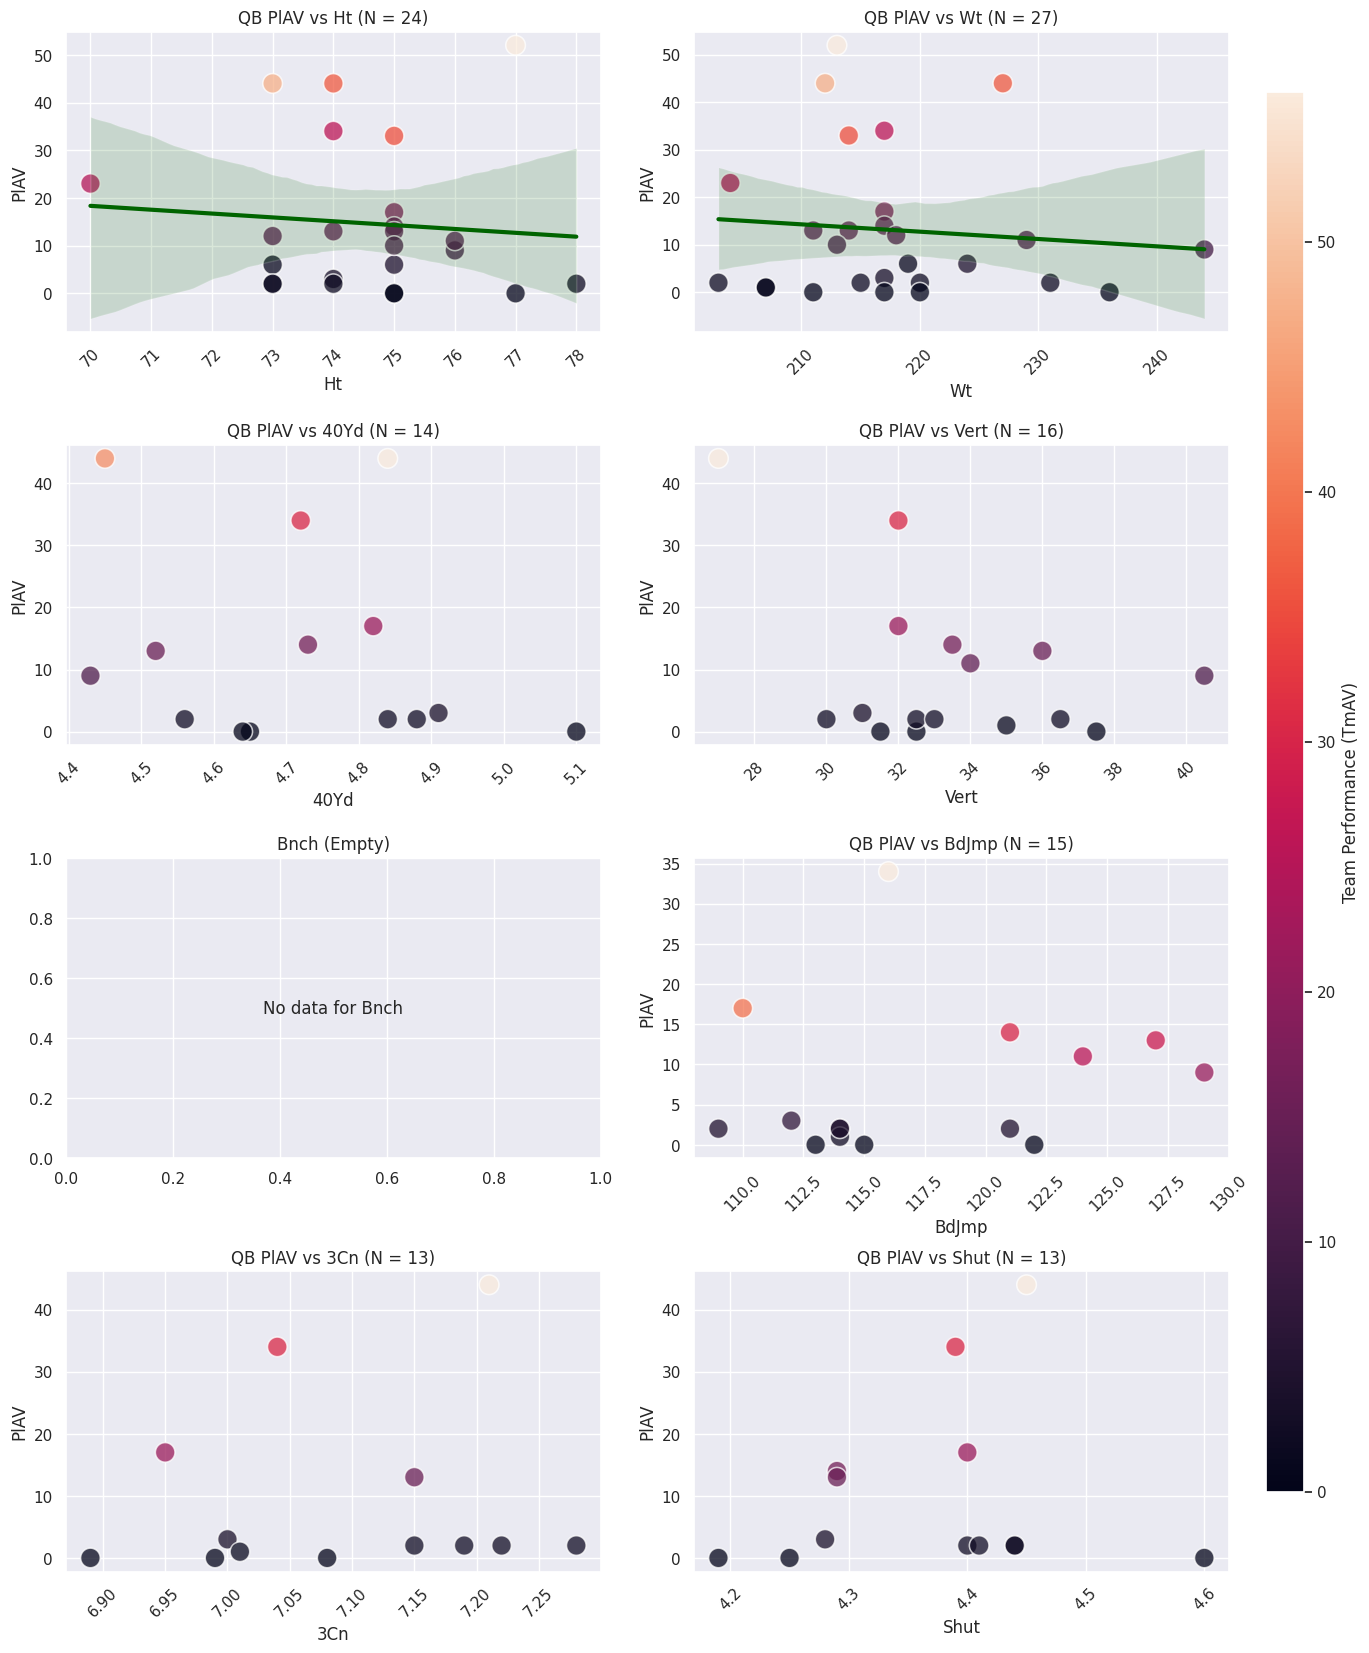

In [133]:
# QB PLOTS
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")
myCmap = sns.color_palette("rocket", as_cmap=True)



# QB PlAV by metrics
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
flat = axes.flatten()

for i, col in enumerate(metrics):
    ax = flat[i]
    data = qbAll.dropna(subset = [col, "PlAV"])
    sampleSize = len(data)
    
    if sampleSize > 0:
        # Scatterplot
        sns.scatterplot(data = data, x = col, y = "PlAV", hue = "TmAV", ax = ax, s = 200, alpha = 0.75, palette = myCmap, legend = False)

        # If sample size is too small can't create a valid prediction line
        if sampleSize >= 20:
            # Prediction line
            sns.regplot(data = data, x = col, y = "PlAV", ax = ax, scatter = False, color = "darkgreen", truncate = True, line_kws = {"linewidth": 3})
        
        ax.set_title(f'QB PlAV vs {col} (N = {sampleSize})') # Titling the graphs based on the col of comparison
        ax.tick_params(axis = "x" , rotation = 45) # Providing easier visibility by rotating the x axis values
    else:
        ax.text(0.5, 0.5, f'No data for {col}', ha = "center", va = "center", fontsize = 12)
        ax.set_title(f'{col} (Empty)')



# Making everything visually appealing
norm = plt.Normalize(defenseAll['TmAV'].min(), defenseAll['TmAV'].max())
sm = plt.cm.ScalarMappable(cmap = myCmap, norm = norm)
sm.set_array([])

cbarAx = fig.add_axes([0.925, 0.15, 0.025, 0.7]) # [left, bottom, width, height]
fig.colorbar(sm, cax = cbarAx, label = "Team Performance (TmAV)")

plt.subplots_adjust(right = 0.9, hspace = 0.375, wspace = 0.175) # Padding

plt.savefig('QBPlots.png', dpi = 300, bbox_inches = "tight")
plt.show()

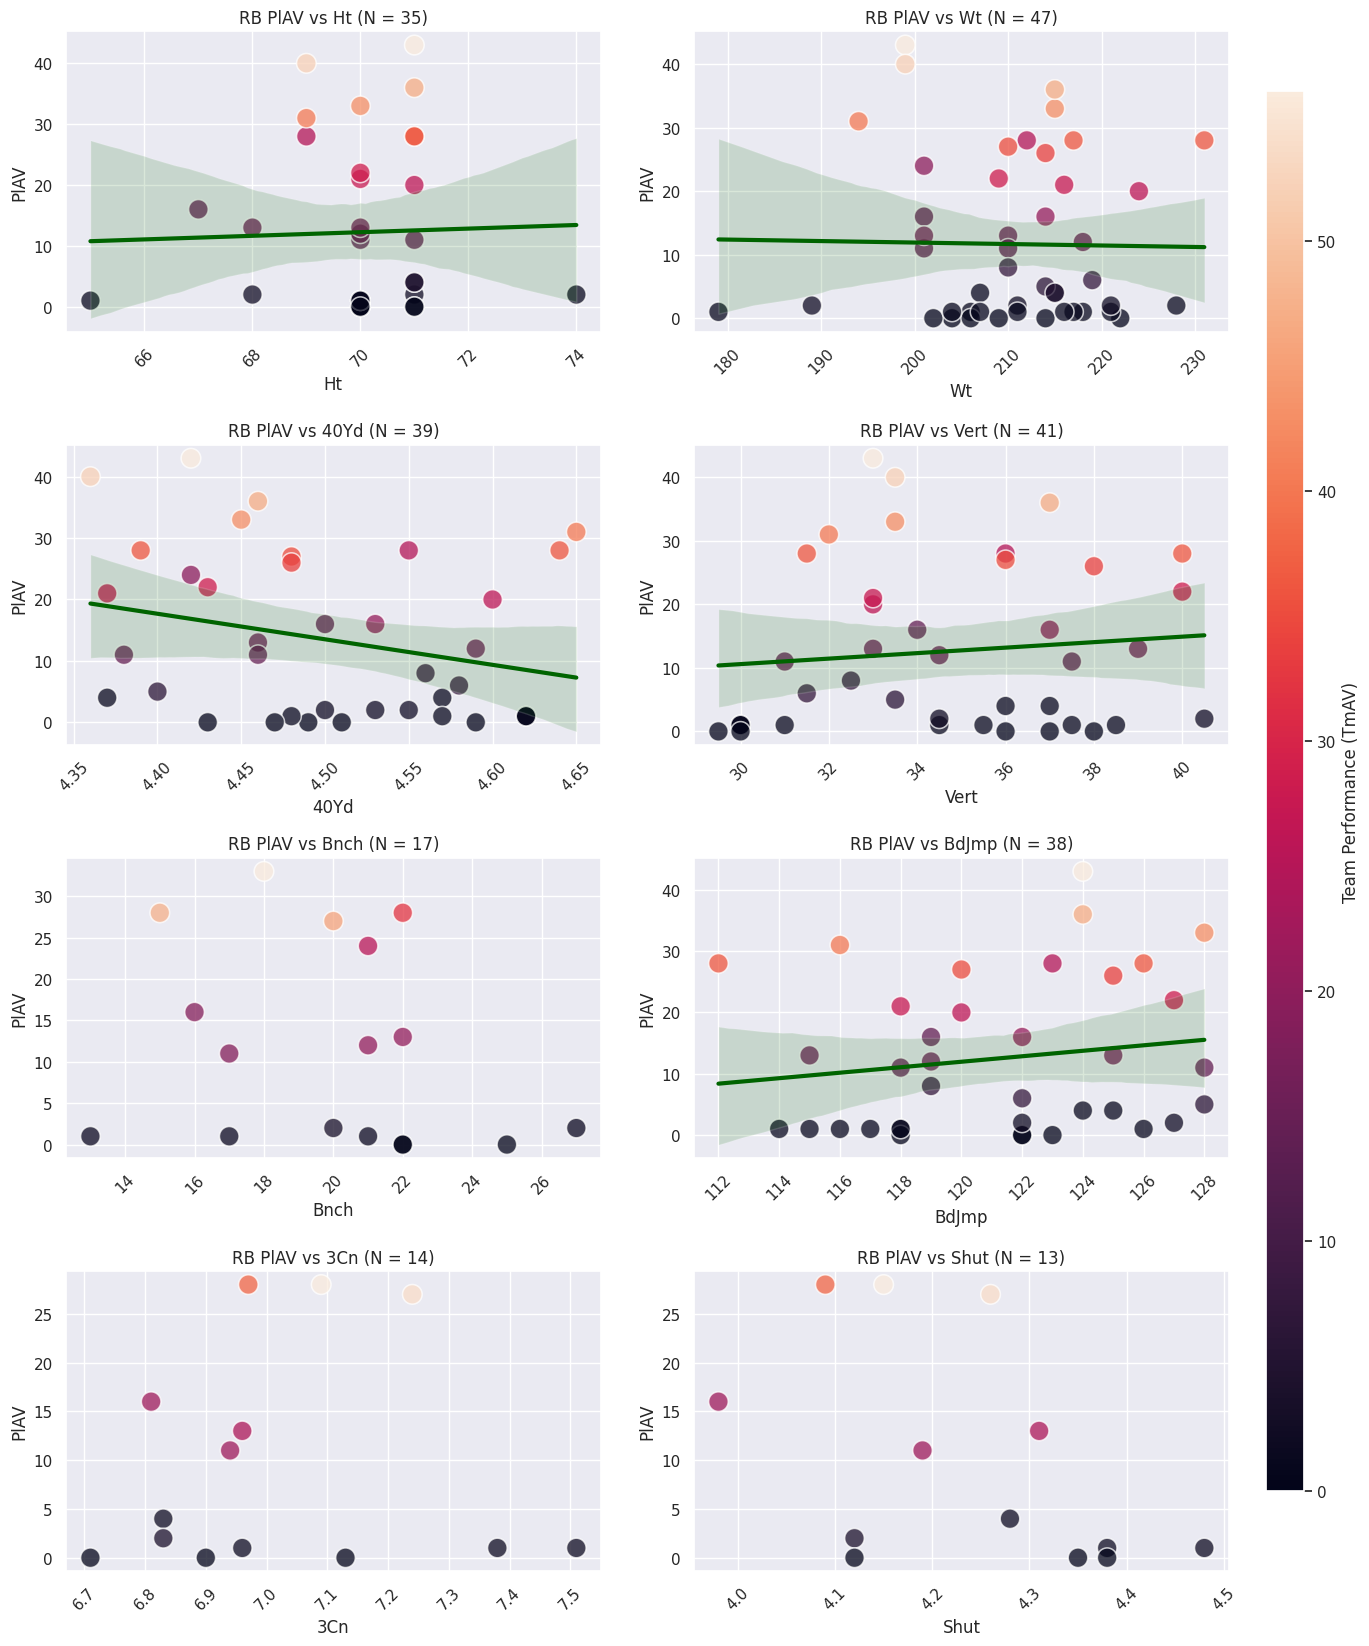

In [134]:
# RB DATA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")
myCmap = sns.color_palette("rocket", as_cmap=True)



# RB PlAV by metrics
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
flat = axes.flatten()

for i, col in enumerate(metrics):
    ax = flat[i]
    data = rbAll.dropna(subset = [col, "PlAV"])
    sampleSize = len(data)
    
    if sampleSize > 0:
        # Scatterplot
        sns.scatterplot(data = data, x = col, y = "PlAV", hue = "TmAV", ax = ax, s = 200, alpha = 0.75, palette = myCmap, legend = False)

        # If sample size is too small can't create a valid prediction line
        if sampleSize >= 20:
            # Prediction line
            sns.regplot(data = data, x = col, y = "PlAV", ax = ax, scatter = False, color = "darkgreen", truncate = True, line_kws = {"linewidth": 3})
        
        ax.set_title(f'RB PlAV vs {col} (N = {sampleSize})') # Titling the graphs based on the col of comparison
        ax.tick_params(axis = "x" , rotation = 45) # Providing easier visibility by rotating the x axis values
    else:
        ax.text(0.5, 0.5, f'No data for {col}', ha = "center", va = "center", fontsize = 12)
        ax.set_title(f'{col} (Empty)')



# Making everything visually appealing
norm = plt.Normalize(defenseAll['TmAV'].min(), defenseAll['TmAV'].max())
sm = plt.cm.ScalarMappable(cmap = myCmap, norm = norm)
sm.set_array([])

cbarAx = fig.add_axes([0.925, 0.15, 0.025, 0.7]) # [left, bottom, width, height]
fig.colorbar(sm, cax = cbarAx, label = "Team Performance (TmAV)")

plt.subplots_adjust(right = 0.9, hspace = 0.375, wspace = 0.175) # Padding

plt.savefig('RBPlots.png', dpi = 300, bbox_inches = "tight")
plt.show()

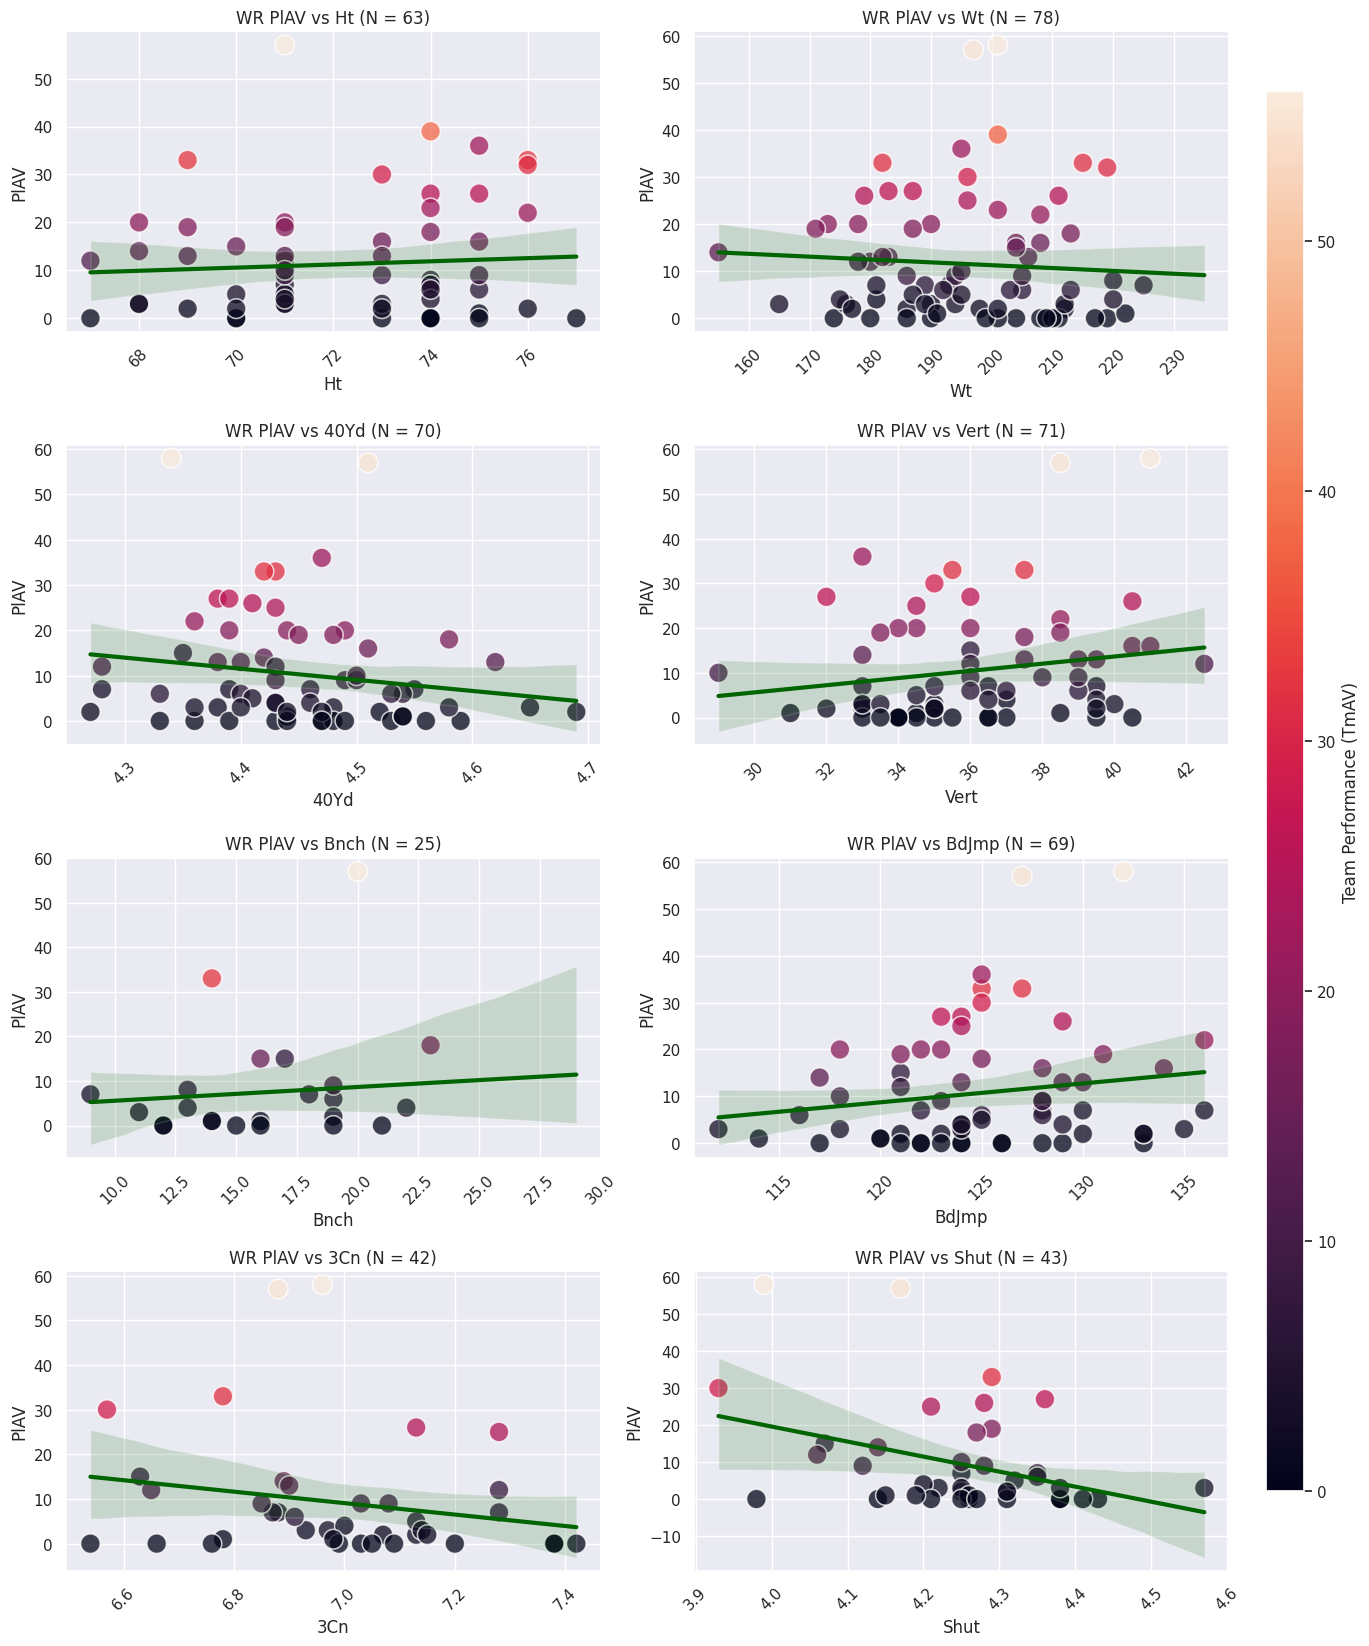

In [135]:
# WR DATA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")
myCmap = sns.color_palette("rocket", as_cmap=True)



# WR PlAV by metrics
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
flat = axes.flatten()

for i, col in enumerate(metrics):
    ax = flat[i]
    data = wrAll.dropna(subset = [col, "PlAV"])
    sampleSize = len(data)
    
    if sampleSize > 0:
        # Scatterplot
        sns.scatterplot(data = data, x = col, y = "PlAV", hue = "TmAV", ax = ax, s = 200, alpha = 0.75, palette = myCmap, legend = False)

        # If sample size is too small can't create a valid prediction line
        if sampleSize >= 20:
            # Prediction line
            sns.regplot(data = data, x = col, y = "PlAV", ax = ax, scatter = False, color = "darkgreen", truncate = True, line_kws = {"linewidth": 3})
        
        ax.set_title(f'WR PlAV vs {col} (N = {sampleSize})') # Titling the graphs based on the col of comparison
        ax.tick_params(axis = "x" , rotation = 45) # Providing easier visibility by rotating the x axis values
    else:
        ax.text(0.5, 0.5, f'No data for {col}', ha = "center", va = "center", fontsize = 12)
        ax.set_title(f'{col} (Empty)')



# Making everything visually appealing
norm = plt.Normalize(defenseAll['TmAV'].min(), defenseAll['TmAV'].max())
sm = plt.cm.ScalarMappable(cmap = myCmap, norm = norm)
sm.set_array([])

cbarAx = fig.add_axes([0.925, 0.15, 0.025, 0.7]) # [left, bottom, width, height]
fig.colorbar(sm, cax = cbarAx, label = "Team Performance (TmAV)")

plt.subplots_adjust(right = 0.9, hspace = 0.375, wspace = 0.175) # Padding

plt.savefig('WRPlots.png', dpi = 300, bbox_inches = "tight")
plt.show()

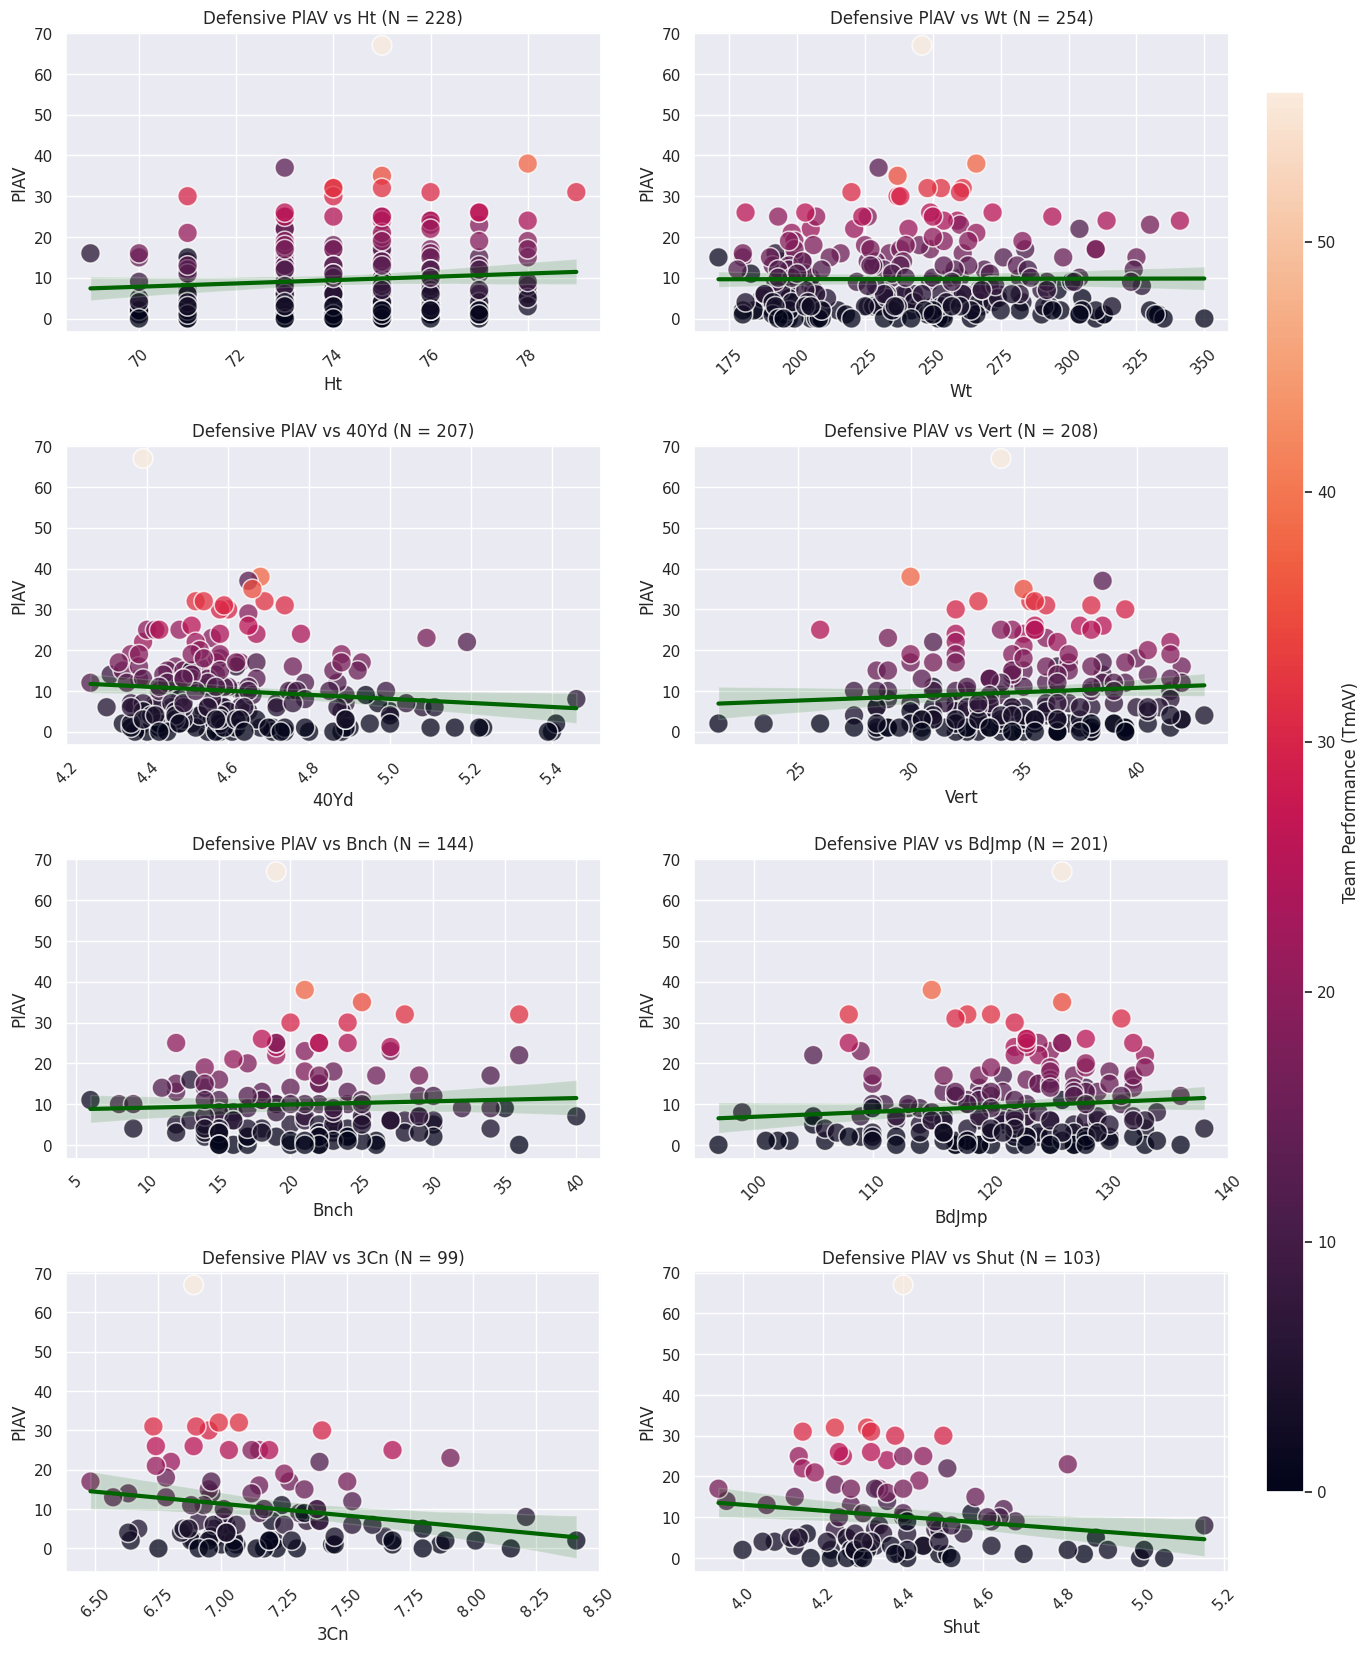

In [136]:
# Defense DATA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "darkgrid")
myCmap = sns.color_palette("rocket", as_cmap=True)



# Defense PlAV by metrics
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
flat = axes.flatten()

for i, col in enumerate(metrics):
    ax = flat[i]
    data = defenseAll.dropna(subset = [col, "PlAV"])
    sampleSize = len(data)
    
    if sampleSize > 0:
        # Scatterplot
        sns.scatterplot(data = data, x = col, y = "PlAV", hue = "TmAV", ax = ax, s = 200, alpha = 0.75, palette = myCmap, legend = False)

        # If sample size is too small can't create a valid prediction line
        if sampleSize >= 20:
            # Prediction line
            sns.regplot(data = data, x = col, y = "PlAV", ax = ax, scatter = False, color = "darkgreen", truncate = True, line_kws = {"linewidth": 3})
        
        ax.set_title(f'Defensive PlAV vs {col} (N = {sampleSize})') # Titling the graphs based on the col of comparison
        ax.tick_params(axis = "x" , rotation = 45) # Providing easier visibility by rotating the x axis values
    else:
        ax.text(0.5, 0.5, f'No data for {col}', ha = "center", va = "center", fontsize = 12)
        ax.set_title(f'{col} (Empty)')



# Making everything visually appealing
norm = plt.Normalize(defenseAll['TmAV'].min(), defenseAll['TmAV'].max())
sm = plt.cm.ScalarMappable(cmap = myCmap, norm = norm)
sm.set_array([])

cbarAx = fig.add_axes([0.925, 0.15, 0.025, 0.7]) # [left, bottom, width, height]
fig.colorbar(sm, cax = cbarAx, label = "Team Performance (TmAV)")

plt.subplots_adjust(right = 0.9, hspace = 0.375, wspace = 0.175) # Padding

plt.savefig('DefensePlots.png', dpi = 300, bbox_inches = "tight")
plt.show()